## Euler-Bernoulli Model with Axial Loads

When a concentrated axial force $F$ acts on the end of an Euler-Bernoulli beam, the vertical displacement $u_y$ is the solution of the following differential equation, with appropriate boundary conditions:

$$
    \frac{d ^ 4 u_y (z)}{d z ^ 4} + \alpha ^ 2 \, \frac{d ^ 2 u_y(z)}{d z ^ 2} = 0
$$

where $\alpha = \sqrt{\frac{F}{E I}}$. Let's solve some problems

### Pinned-Roller Beam

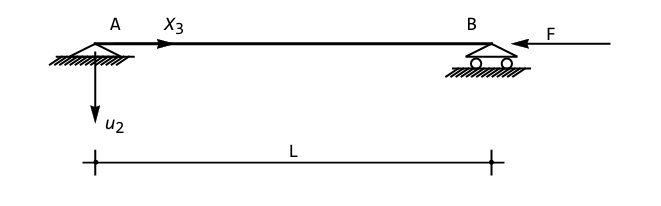

In [1]:
# Importing SymPy
import sympy as smp

In [2]:
# Symbols
L, E, I = smp.symbols("L E I", real = True, positive = True, constant = True)
alpha, F = smp.symbols("alpha F", real = True, positive = True)

z = smp.symbols("z", real = True)
uy = smp.Function("u_y", real = True)(z)

In [3]:
# Setting the core differential equation
eq = smp.Eq(smp.diff(uy, z, 4) + alpha ** 2 * smp.diff(uy, z, 2), 0)
eq

Eq(alpha**2*Derivative(u_y(z), (z, 2)) + Derivative(u_y(z), (z, 4)), 0)

In [4]:
# General solution
sol = smp.dsolve(eq, uy)
sol = sol.rhs
sol

C1 + C2*z + C3*sin(alpha*z) + C4*cos(alpha*z)

In [5]:
# Unknown constants
C1 = sol.args[0]
C2 = sol.args[1] / z
C3 = sol.args[2] / smp.sin(alpha * z)
C4 = sol.args[3] / smp.cos(alpha * z)

In [6]:
# Condition 1: uy(0) = 0
eq1 = smp.Eq(sol.subs(z, 0), 0)
eq1

Eq(C1 + C4, 0)

In [7]:
# Condition 2: uy''(0) = 0
eq2 = smp.Eq(smp.diff(sol, z, 2).subs(z, 0), 0)
eq2

Eq(-C4*alpha**2, 0)

In [8]:
# Condition 3: uy(L) = 0
eq3 = smp.Eq(sol.subs(z, L), 0)
eq3

Eq(C1 + C2*L + C3*sin(L*alpha) + C4*cos(L*alpha), 0)

In [9]:
# Condition 4: uy''(L) = 0
eq4 = smp.Eq(smp.diff(sol, z, 2).subs(z, L), 0)
eq4

Eq(-alpha**2*(C3*sin(L*alpha) + C4*cos(L*alpha)), 0)

In [10]:
# Getting the system's matrix: A * x = b
eq_list = [eq1, eq2, eq3, eq4]

A, b = smp.linear_eq_to_matrix(eq_list, [C1, C2, C3, C4])

In [11]:
A

Matrix([
[1, 0,                      0,                      1],
[0, 0,                      0,              -alpha**2],
[1, L,           sin(L*alpha),           cos(L*alpha)],
[0, 0, -alpha**2*sin(L*alpha), -alpha**2*cos(L*alpha)]])

In [12]:
b

Matrix([
[0],
[0],
[0],
[0]])

In [13]:
# Alpha for non-trivial solutions
smp.solveset(smp.Eq(A.det(), 0), alpha)

Union(ImageSet(Lambda(_n, (2*_n*pi + pi)/L), Integers), ImageSet(Lambda(_n, 2*_n*pi/L), Integers))

This is equivalent to:

$$
\alpha_C = n \, \frac{\pi}{L}
$$

In [14]:
# Defining critical values of alpha
n = smp.symbols("n", real = True, integer = True, positive = True)
alpha_critical = n * smp.pi / L

In [15]:
# Critical force's values
smp.solve(smp.Eq(alpha_critical, smp.sqrt(F / (E * I))), F)[0]

pi**2*E*I*n**2/L**2

In [16]:
# Solving the system
smp.linsolve((A.subs(alpha, alpha_critical), b), [C1, C2, C3, C4])

{(0, 0, C3, 0)}

In [17]:
# Critical solutions
sol_critical = sol.subs([(C1, 0),
                         (C2, 0),
                         (C4, 0),
                         (alpha, alpha_critical)])
sol_critical

C3*sin(pi*n*z/L)

### Fixed Beam

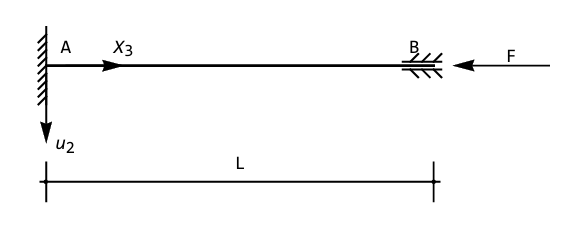

In [18]:
eq1 = smp.Eq(sol.subs(z, 0), 0) # Condition 1: uy(0) = 0
eq2 = smp.Eq(smp.diff(sol, z, 1).subs(z, 0), 0) # Condition 2: uy'(0) = 0
eq3 = smp.Eq(sol.subs(z, L), 0) # Condition 3: uy(L) = 0
eq4 = smp.Eq(smp.diff(sol, z, 1).subs(z, L), 0) # Condition 4: uy'(L) = 0

eq_list = [eq1, eq2, eq3, eq4]
A, b = smp.linear_eq_to_matrix(eq_list, [C1, C2, C3, C4])
A # System matrix

Matrix([
[1, 0,                  0,                   1],
[0, 1,              alpha,                   0],
[1, L,       sin(L*alpha),        cos(L*alpha)],
[0, 1, alpha*cos(L*alpha), -alpha*sin(L*alpha)]])

In [19]:
# Determinant of A
det = A.det()
det

L*alpha**2*sin(L*alpha) - alpha*sin(L*alpha)**2 - alpha*cos(L*alpha)**2 + 2*alpha*cos(L*alpha) - alpha

In [20]:
# Simplifying it
det = det.rewrite(smp.tan).factor() / (2 * alpha)
det

(L*alpha - 2*tan(L*alpha/2))*tan(L*alpha/2)/(tan(L*alpha/2)**2 + 1)

In [21]:
# Consider only the numerator
det = smp.numer(det)
det

(L*alpha - 2*tan(L*alpha/2))*tan(L*alpha/2)

In [22]:
eq1 = smp.Eq(det.args[0] / 2, 0) # First equation
eq2 = smp.Eq(det.args[1], 0) # Second equation

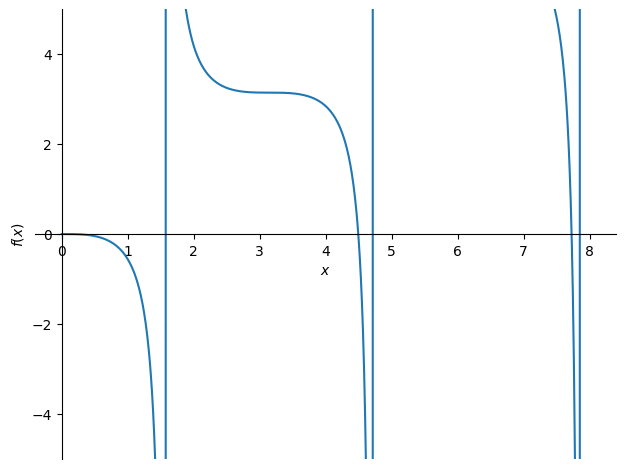

In [ ]:
# Solving the first equation numerically
x = smp.symbols("x", real = True)
eq1 = eq1.subs(alpha * L / 2, x)
smp.plot(eq1.lhs, (x, 0, 8), ylim = (- 5, 5)) # Plotting x - tan(x)

In [24]:
# First value
smp.nsolve(eq1, 4.5)

4.49340945790906

In [25]:
# Second value...
smp.nsolve(eq1, 7.5)

7.72525183693771

In [26]:
# Solving the second equation analitically
smp.solveset(eq2, alpha)

ImageSet(Lambda(_n, 2*_n*pi/L), Integers)

In [27]:
# Computing critical forces
alpha_critical = 2 * n * smp.pi / L
smp.solve(smp.Eq(alpha_critical, smp.sqrt(F / (E * I))), F)[0]

4*pi**2*E*I*n**2/L**2

In [28]:
# Solving the system
smp.linsolve((A.subs(alpha, alpha_critical), b), [C1, C2, C3, C4])

{(-C4, 0, 0, C4)}

In [29]:
# Critical solutions
sol_critical = sol.subs([(C1, - C4),
                         (C2, 0),
                         (C3, 0),
                         (alpha, alpha_critical)]).factor()
sol_critical

C4*(cos(2*pi*n*z/L) - 1)

### Cantilever Beam

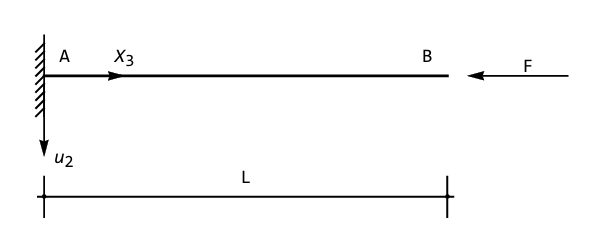

In [30]:
eq1 = smp.Eq(sol.subs(z, 0), 0) # Condition 1: uy(0) = 0
eq2 = smp.Eq(smp.diff(sol, z, 1).subs(z, 0), 0) # Condition 2: uy'(0) = 0
eq3 = smp.Eq(smp.diff(sol, z, 2).subs(z, L), 0) # Condition 3: uy''(L) = 0
eq4 = smp.Eq(smp.diff(sol, z, 3).subs(z, L) + alpha ** 2 * smp.diff(sol, z, 1).subs(z, L), 0) # Condition on the free end of the beam: uy'''(L) + alpha^2 * uy'(L) = 0

eq_list = [eq1, eq2, eq3, eq4]
A, b = smp.linear_eq_to_matrix(eq_list, [C1, C2, C3, C4])
A # System matrix

Matrix([
[1,        0,                      0,                      1],
[0,        1,                  alpha,                      0],
[0,        0, -alpha**2*sin(L*alpha), -alpha**2*cos(L*alpha)],
[0, alpha**2,                      0,                      0]])

In [31]:
# Finding critical alpha's values
det = A.det()
smp.solveset(det, alpha)

Union({0}, ImageSet(Lambda(_n, (2*_n*pi + pi/2)/L), Integers), ImageSet(Lambda(_n, (2*_n*pi + 3*pi/2)/L), Integers))

$0$ is the trivial solution. We can write:

$$
\alpha = \frac{n \pi + \frac{\pi}{2}}{L}
$$

In [32]:
# Computing critical forces
alpha_critical = (smp.pi / 2 + n * smp.pi) / L
smp.solve(smp.Eq(alpha_critical, smp.sqrt(F / (E * I))), F)[0]

pi**2*E*I*(2*n + 1)**2/(4*L**2)

In [33]:
# Solving the system
smp.linsolve((A.subs(alpha, alpha_critical), b), [C1, C2, C3, C4])

{(-C4, 0, 0, C4)}

In [34]:
# Critical solutions
sol_critical = sol.subs([(C1, - C4),
                         (C2, 0),
                         (C3, 0),
                         (alpha, alpha_critical)]).factor()
sol_critical

C4*(cos(pi*n*z/L + pi*z/(2*L)) - 1)